[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)][def]

[def]: https://colab.research.google.com/github/LEE-Sanghoon/MNT2009/blob/main/HandsOn-인공신경망소개.ipynb

# 인공 신경망 Artificial Neural Network (ANN)

## 인공 뉴런

인공 뉴런(artificial neuron)
- 1943년, 신경생리학자 워런 매컬러(Warren McCulloch)와 수학자 월터 피츠(Wallter Pitts)가 제안
- 하나 이상의 이진(on/off) 입력과 하나의 이진 출력
- 특징:
  - 이진 임계값 함수를 사용 → 연속적인 값 출력 불가
  - 가중치 또는 연결을 조정하는 학습 매커니즘이 없음
  - 비선형 관계를 모델링 할 수 없음

- McCulloch-Pittes Neuron 예제:  
  입력 x와 가중치 w의 합이 threshold 이상이면 1, 그렇지 않으면 0을 출력하는 간단한 모델

In [2]:
class MCPNeuron:
    def __init__(self, weights, threshold):
        self.weights = weights
        self.threshold = threshold
    
    def activate(self, inputs):
        if len(inputs) != len(self.weights):
            raise ValueError("입력 개수와 가중치 개수가 같아야 합니다.")
        
        total_input = sum(x * w for x, w in zip(inputs, self.weights))
        
        return 1 if total_input >= self.threshold else 0    

In [6]:
def test_gate(name, neuron, test_cases):
    print(f"\n{name} gate:")
    print("-" * 20)
    
    for inputs in test_cases:
        output = neuron.activate(inputs)
        print(f"Inputs: {inputs} -> Output: {output}")

In [7]:
and_neuron = MCPNeuron(weights=[1, 1], threshold=2)
or_neuron = MCPNeuron(weights=[1, 1], threshold=1)
not_neuron = MCPNeuron(weights=[-1], threshold=0)

binary_inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
not_inputs = [(0,), (1,)]

test_gate("AND", and_neuron, binary_inputs)
test_gate("OR", or_neuron, binary_inputs)
test_gate("NOT", not_neuron, not_inputs)



AND gate:
--------------------
Inputs: (0, 0) -> Output: 0
Inputs: (0, 1) -> Output: 0
Inputs: (1, 0) -> Output: 0
Inputs: (1, 1) -> Output: 1

OR gate:
--------------------
Inputs: (0, 0) -> Output: 0
Inputs: (0, 1) -> Output: 1
Inputs: (1, 0) -> Output: 1
Inputs: (1, 1) -> Output: 1

NOT gate:
--------------------
Inputs: (0,) -> Output: 1
Inputs: (1,) -> Output: 0


## 퍼셉트론

- 퍼셉트론 (perceptron)
  - 가장 간단한 인공 신경망 구조 중 하나
  - 1957년에 프랑크 로젠블라트 Frank Rosenblatt 가 제안
  - 퍼셉트론은 TLU (threshold logic unit) 또는 LTU (Linear threshold unit)의 변형으로 분류
  - MCP neron과의 비교:  
    MCP neuron 은 사람이 가중치와 임계값을 직접 정하는 논리 뉴론이고, Perceptron 은 데이터를 통해 가중치와 bias를 학습할 수 있는 뉴론  
    둘 다 기본 형태에서는 선형 분리 가능한 문제만 해결 할 수 있음

In [9]:
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        self.weights = [0.0 for _ in range(input_size)]
        self.bias = 0.0
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def activate(self, weighted_sum):
        return 1 if weighted_sum >= 0 else 0
    
    def predict(self, inputs):
        if len(inputs) != len(self.weights):
            raise ValueError("입력 개수와 가중치 개수가 같아야 합니다.")
        
        weighted_sum = sum(x * w for x, w in zip(inputs, self.weights)) + self.bias
        return self.activate(weighted_sum)
    
    def train(self, training_inputs, labels):
        for epoch in range(self.epochs):
            print(f"\nEpoch {epoch + 1}")
            print("-" * 20)
            
            total_error = 0
            
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                error = label - prediction
                total_error += abs(error)

                for i in range(len(self.weights)):
                    self.weights[i] += self.learning_rate * error * inputs[i]
                    
                self.bias += self.learning_rate * error
                
                print(
                    f"Inputs: {inputs}, Label: {label}, Prediction: {prediction}, "
                    f"Error: {error}, Weights: {self.weights}, Bias: {self.bias}"                    
                )
                
            if total_error == 0:
                print("모든 데이터에 대해 정확히 예측했습니다. 학습 종료합니다.")
                break

In [10]:
def test_perceptron(name, perceptron, test_cases):
    print(f"\n{name} Perceptron Test:")
    print("-" * 20)
    
    for inputs in test_cases:
        output = perceptron.predict(inputs)
        print(f"Inputs: {inputs} -> Output: {output}")

training_inputs = [
    (0, 0), 
    (0, 1), 
    (1, 0), 
    (1, 1)
]

labels = [
    0, 
    0, 
    0, 
    1
]

perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
perceptron.train(training_inputs, labels)

test_perceptron("AND", perceptron, training_inputs)


Epoch 1
--------------------
Inputs: (0, 0), Label: 0, Prediction: 1, Error: -1, Weights: [0.0, 0.0], Bias: -0.1
Inputs: (0, 1), Label: 0, Prediction: 0, Error: 0, Weights: [0.0, 0.0], Bias: -0.1
Inputs: (1, 0), Label: 0, Prediction: 0, Error: 0, Weights: [0.0, 0.0], Bias: -0.1
Inputs: (1, 1), Label: 1, Prediction: 0, Error: 1, Weights: [0.1, 0.1], Bias: 0.0

Epoch 2
--------------------
Inputs: (0, 0), Label: 0, Prediction: 1, Error: -1, Weights: [0.1, 0.1], Bias: -0.1
Inputs: (0, 1), Label: 0, Prediction: 1, Error: -1, Weights: [0.1, 0.0], Bias: -0.2
Inputs: (1, 0), Label: 0, Prediction: 0, Error: 0, Weights: [0.1, 0.0], Bias: -0.2
Inputs: (1, 1), Label: 1, Prediction: 0, Error: 1, Weights: [0.2, 0.1], Bias: -0.1

Epoch 3
--------------------
Inputs: (0, 0), Label: 0, Prediction: 0, Error: 0, Weights: [0.2, 0.1], Bias: -0.1
Inputs: (0, 1), Label: 0, Prediction: 1, Error: -1, Weights: [0.2, 0.0], Bias: -0.2
Inputs: (1, 0), Label: 0, Prediction: 1, Error: -1, Weights: [0.1, 0.0], Bias

---
- **[실습과제]** OR, NAND 게이트를 Perceptron으로 학습히시오. 그리고 XOR 게이트를 단일 Perceptron으로 학습이 되는지 확인 하시오.

In [ ]:
# OR 게이트 학습
pass

# NAND 게이트 학습
pass

# XOR 게이트 학습
pass

---

## 다층 퍼셉트론

- 다층 퍼셉트론(Multi-Layer Perceptron, MLP)
  - 입력층(input layer) 하나와 은닉층(hidden layer)으로 불리우는 하나 이상의 TLU 층과 마지막 출력층(output layer)으로 구성
  - 출력층을 제외하고 모든 층은 편향 뉴론(bias neuron)을 포함하며 다음 층과 완전히 연결(fully connected)
  - 신호가 입력에서 출력으로 한 방향으로만 흐른다는 점에서 이 구조는 피드포워드 신경망(FNN, feedforward neural network)으로 분류
   
  은닉층을 여러개 쌓아 올린 인공 신경망을 심층 신경망(DNN, deep neural network) 이라고 한다. 일반적으로 얕더라도 신경망이 사용되면 **딥러닝** 이라고 한다.

- 다층 퍼셉트론 학습
  - 훈련(학습) 방법을 찾기 위해서 많은 연구자들이 고군분투 했지만 성고하지 못하다가, 1986년 루멜파트, 제프리 힌턴, 로날드 윌리엄스가 역전파(backpropagasion) 훈련 알고리즘을 제안

  - 역전파 알고리즘
    1. (정방향 계산) 각 훈련 샘플에 대해 예측을 계산한다.
    2. (역방향 계산) 역방향으로 각 층을 거치면서 각 연결이 오차에 기여한 정도를 측정한다.
    3. (경사 하강법 단계) 오차가 감소하도록 가중치를 조정한다.

- XOR 게이트를 학습하는 MLP

    XOR 게이트 학습을 위해서 다음의 구조로 작성
    ```
    입력층 : 2개 뉴런
    은닉층 : 2개 뉴런
    출력층 : 1개 뉴런
    ```  
    활성화 함수는 sigmoid를 사용하고, 학습은 역전파 backpropagation으로 진행

In [12]:
import math
import random

class MLP:
    def __init__(self, input_size=2, hidden_size=2, output_size=1, learning_rate=0.5, epochs=10000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        random.seed(42)

        # 입력층 -> 은닉층 가중치
        self.weights_input_hidden = [
            [random.uniform(-1, 1) for _ in range(hidden_size)]
            for _ in range(input_size)
        ]

        # 은닉층 bias
        self.bias_hidden = [
            random.uniform(-1, 1) for _ in range(hidden_size)
        ]

        # 은닉층 -> 출력층 가중치
        self.weights_hidden_output = [
            [random.uniform(-1, 1) for _ in range(output_size)]
            for _ in range(hidden_size)
        ]

        # 출력층 bias
        self.bias_output = [
            random.uniform(-1, 1) for _ in range(output_size)
        ]

    def sigmoid(self, x):
        return 1 / (1 + math.exp(-x))

    def sigmoid_derivative(self, y):
        # y는 sigmoid(x)의 결과값
        return y * (1 - y)

    def forward(self, inputs):
        # 은닉층 계산
        hidden_inputs = []
        for j in range(self.hidden_size):
            total = self.bias_hidden[j]
            for i in range(self.input_size):
                total += inputs[i] * self.weights_input_hidden[i][j]
            hidden_inputs.append(total)

        hidden_outputs = [
            self.sigmoid(value) for value in hidden_inputs
        ]

        # 출력층 계산
        final_inputs = []
        for k in range(self.output_size):
            total = self.bias_output[k]
            for j in range(self.hidden_size):
                total += hidden_outputs[j] * self.weights_hidden_output[j][k]
            final_inputs.append(total)

        final_outputs = [
            self.sigmoid(value) for value in final_inputs
        ]

        return hidden_outputs, final_outputs

    def predict(self, inputs):
        _, outputs = self.forward(inputs)
        # XOR 결과는 0 또는 1로 보고 싶으므로 0.5 기준으로 변환
        return 1 if outputs[0] >= 0.5 else 0

    def predict_raw(self, inputs):
        _, outputs = self.forward(inputs)
        return outputs[0]

    def train(self, training_inputs, labels):
        for epoch in range(self.epochs):
            total_error = 0
            for inputs, label in zip(training_inputs, labels):
                # 1. 순전파
                hidden_outputs, final_outputs = self.forward(inputs)
                target = label
                prediction = final_outputs[0]

                # 2. 오차 계산
                error = target - prediction
                total_error += error ** 2

                # 3. 출력층 delta 계산
                output_delta = error * self.sigmoid_derivative(prediction)

                # 4. 은닉층 delta 계산
                hidden_deltas = []
                for j in range(self.hidden_size):
                    hidden_error = output_delta * self.weights_hidden_output[j][0]
                    hidden_delta = hidden_error * self.sigmoid_derivative(hidden_outputs[j])
                    hidden_deltas.append(hidden_delta)

                # 5. 은닉층 -> 출력층 가중치 업데이트
                for j in range(self.hidden_size):
                    self.weights_hidden_output[j][0] += (
                        self.learning_rate * output_delta * hidden_outputs[j]
                    )
                self.bias_output[0] += self.learning_rate * output_delta

                # 6. 입력층 -> 은닉층 가중치 업데이트
                for i in range(self.input_size):
                    for j in range(self.hidden_size):
                        self.weights_input_hidden[i][j] += (
                            self.learning_rate * hidden_deltas[j] * inputs[i]
                        )

                for j in range(self.hidden_size):
                    self.bias_hidden[j] += self.learning_rate * hidden_deltas[j]

            # 1000번마다 오차 출력
            if (epoch + 1) % 1000 == 0:
                print(f"Epoch {epoch + 1}, total_error: {total_error:.6f}")

            # 충분히 작아지면 조기 종료
            if total_error < 0.01:
                print(f"\nEpoch {epoch + 1}에서 학습 완료")
                print(f"total_error: {total_error:.6f}")
                break

In [13]:
def test_mlp(name, mlp, test_inputs, labels):
    print(f"\n{name} 테스트")
    print("-" * 40)

    for inputs, label in zip(test_inputs, labels):
        raw_output = mlp.predict_raw(inputs)
        predicted_class = mlp.predict(inputs)
        print(
            f"입력: {inputs}, "
            f"정답: {label}, "
            f"출력값: {raw_output:.4f}, "
            f"분류 결과: {predicted_class}"
        )
        
training_inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

xor_labels = [
    0,
    1,
    1,
    0
]

mlp = MLP(
    input_size=2,
    hidden_size=2,
    output_size=1,
    learning_rate=0.5,
    epochs=10000
)

mlp.train(training_inputs, xor_labels)
test_mlp("XOR MLP", mlp, training_inputs, xor_labels)

Epoch 1000, total_error: 0.039235

Epoch 1953에서 학습 완료
total_error: 0.009994

XOR MLP 테스트
----------------------------------------
입력: [0, 0], 정답: 0, 출력값: 0.0431, 분류 결과: 0
입력: [0, 1], 정답: 1, 출력값: 0.9526, 분류 결과: 1
입력: [1, 0], 정답: 1, 출력값: 0.9524, 분류 결과: 1
입력: [1, 1], 정답: 0, 출력값: 0.0599, 분류 결과: 0


- Scikit-learn을 이용한 XOR 게이트 학습 예제

X:
[[1 1]
 [1 0]
 [0 1]
 [0 0]]

y:
[0 1 1 0]

========== Epoch 1 ==========

[입력층 -> 은닉층 weights]
          h1        h2
x1 -0.171367  0.633752
x2  0.330620  0.136886

[은닉층 bias]
         h1        h2
0 -0.479446 -0.491329

[은닉층 -> 출력층 weights]
           y
h1 -0.736097
h2  0.578528

[출력층 bias]
          y
0  0.126873
Loss: 0.6972783086853707
Prediction: [1 1 1 1]
Accuracy: 0.5

========== Epoch 10 ==========

[입력층 -> 은닉층 weights]
          h1        h2
x1 -0.101907  0.611156
x2  0.315636  0.132758

[은닉층 bias]
         h1        h2
0 -0.459693 -0.488637

[은닉층 -> 출력층 weights]
           y
h1 -0.743705
h2  0.520477

[출력층 bias]
         y
0  0.06096
Loss: 0.6937804606790293
Prediction: [1 1 0 0]
Accuracy: 0.5

========== Epoch 100 ==========

[입력층 -> 은닉층 weights]
          h1        h2
x1  0.340727  0.633114
x2  0.281816  0.327857

[은닉층 bias]
         h1        h2
0 -0.631793 -0.208706

[은닉층 -> 출력층 weights]
           y
h1 -0.749436
h2  0.419942

[출력층 bias]
          y
0  0.080127
Loss: 

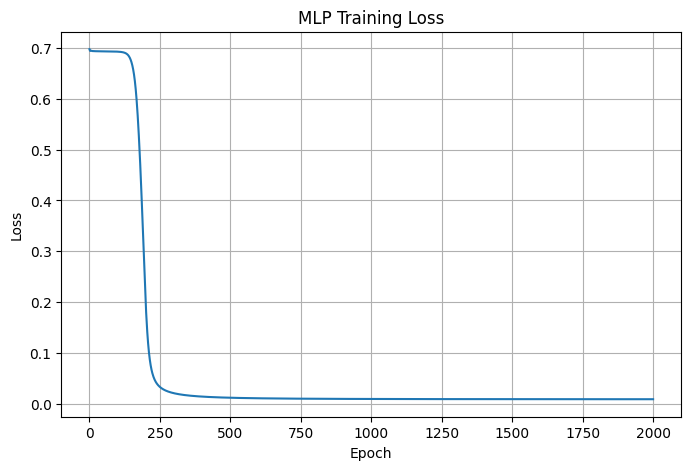

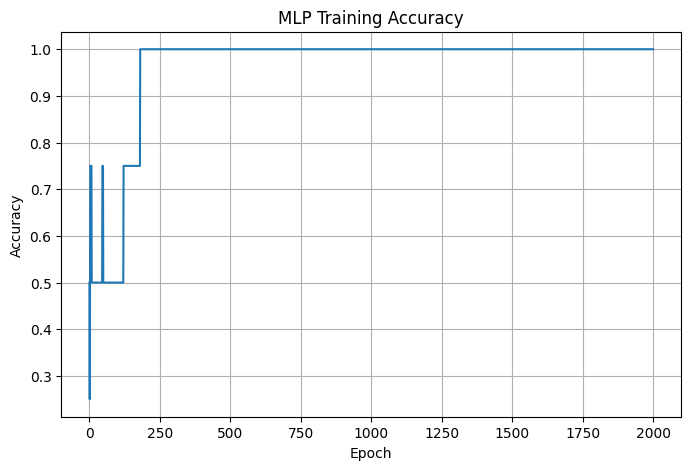

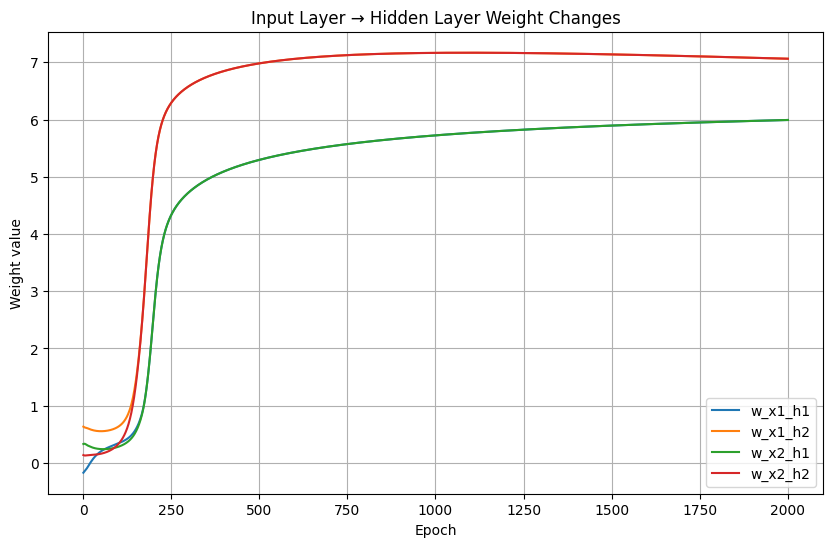

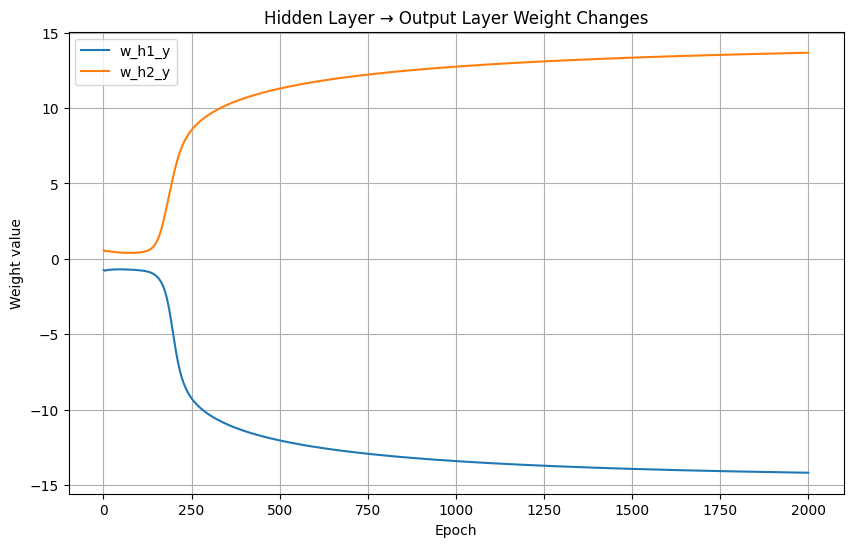

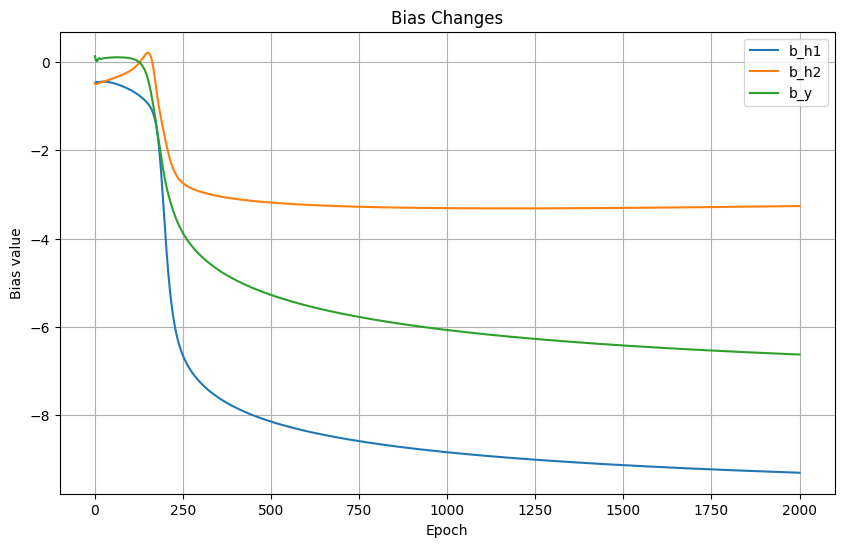

In [3]:
# pip install scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# ============================================================
# 1. XOR 데이터셋
# ============================================================

# 입력 데이터: p, q
X = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0]
])

# 정답: p xor q
y = np.array([0, 1, 1, 0])

print("X:")
print(X)
print("\ny:")
print(y)


# ============================================================
# 2. MLP 모델 생성
# ============================================================

mlp = MLPClassifier(
    hidden_layer_sizes=(2,),   # 은닉층 1개, 은닉 뉴런 2개
    activation="logistic",     # sigmoid 함수
    solver="sgd",              # weight 변화를 보기 좋게 SGD 사용
    learning_rate_init=0.5,
    max_iter=1,                # partial_fit에서 한 번씩 학습
    warm_start=True,
    random_state=42
)


# ============================================================
# 3. weight 모니터링 함수
# ============================================================

def print_weights(model, epoch):
    """
    Scikit-learn MLPClassifier의 weight와 bias를 출력하는 함수

    model.coefs_[0]      : 입력층 -> 은닉층 weight
    model.coefs_[1]      : 은닉층 -> 출력층 weight
    model.intercepts_[0] : 은닉층 bias
    model.intercepts_[1] : 출력층 bias
    """

    print(f"\n========== Epoch {epoch} ==========")

    print("\n[입력층 -> 은닉층 weights]")
    print(pd.DataFrame(
        model.coefs_[0],
        index=["x1", "x2"],
        columns=["h1", "h2"]
    ))

    print("\n[은닉층 bias]")
    print(pd.DataFrame(
        model.intercepts_[0].reshape(1, -1),
        columns=["h1", "h2"]
    ))

    print("\n[은닉층 -> 출력층 weights]")
    print(pd.DataFrame(
        model.coefs_[1],
        index=["h1", "h2"],
        columns=["y"]
    ))

    print("\n[출력층 bias]")
    print(pd.DataFrame(
        model.intercepts_[1].reshape(1, -1),
        columns=["y"]
    ))


# ============================================================
# 4. 학습하면서 weight 변화 저장
# ============================================================

classes = np.array([0, 1])

history = {
    "epoch": [],
    "loss": [],
    "accuracy": [],
    "w_x1_h1": [],
    "w_x1_h2": [],
    "w_x2_h1": [],
    "w_x2_h2": [],
    "w_h1_y": [],
    "w_h2_y": [],
    "b_h1": [],
    "b_h2": [],
    "b_y": []
}

n_epochs = 2000

for epoch in range(1, n_epochs + 1):
    # partial_fit은 한 번 호출할 때마다 조금씩 weight를 업데이트함
    mlp.partial_fit(X, y, classes=classes)

    y_pred = mlp.predict(X)
    acc = accuracy_score(y, y_pred)

    # 현재 weight와 bias
    W_input_hidden = mlp.coefs_[0]
    W_hidden_output = mlp.coefs_[1]
    b_hidden = mlp.intercepts_[0]
    b_output = mlp.intercepts_[1]

    history["epoch"].append(epoch)
    history["loss"].append(mlp.loss_)
    history["accuracy"].append(acc)

    history["w_x1_h1"].append(W_input_hidden[0, 0])
    history["w_x1_h2"].append(W_input_hidden[0, 1])
    history["w_x2_h1"].append(W_input_hidden[1, 0])
    history["w_x2_h2"].append(W_input_hidden[1, 1])

    history["w_h1_y"].append(W_hidden_output[0, 0])
    history["w_h2_y"].append(W_hidden_output[1, 0])

    history["b_h1"].append(b_hidden[0])
    history["b_h2"].append(b_hidden[1])
    history["b_y"].append(b_output[0])

    # 500 epoch마다 weight 출력
    if epoch in [1, 10, 100, 500, 1000, 2000]:
        print_weights(mlp, epoch)
        print("Loss:", mlp.loss_)
        print("Prediction:", y_pred)
        print("Accuracy:", acc)


history_df = pd.DataFrame(history)


# ============================================================
# 5. 최종 결과 확인
# ============================================================

print("\n\n========== 최종 예측 결과 ==========")

final_pred = mlp.predict(X)
final_proba = mlp.predict_proba(X)

result_df = pd.DataFrame({
    "p": X[:, 0],
    "q": X[:, 1],
    "target_xor": y,
    "predicted": final_pred,
    "prob_class_0": final_proba[:, 0],
    "prob_class_1": final_proba[:, 1]
})

print(result_df)

print("\n최종 정확도:", accuracy_score(y, final_pred))


# ============================================================
# 6. loss 변화 시각화
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.grid(True)
plt.show()


# ============================================================
# 7. accuracy 변화 시각화
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training Accuracy")
plt.grid(True)
plt.show()


# ============================================================
# 8. 입력층 -> 은닉층 weight 변화 시각화
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["w_x1_h1"], label="w_x1_h1")
plt.plot(history_df["epoch"], history_df["w_x1_h2"], label="w_x1_h2")
plt.plot(history_df["epoch"], history_df["w_x2_h1"], label="w_x2_h1")
plt.plot(history_df["epoch"], history_df["w_x2_h2"], label="w_x2_h2")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.title("Input Layer → Hidden Layer Weight Changes")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 9. 은닉층 -> 출력층 weight 변화 시각화
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["w_h1_y"], label="w_h1_y")
plt.plot(history_df["epoch"], history_df["w_h2_y"], label="w_h2_y")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.title("Hidden Layer → Output Layer Weight Changes")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 10. bias 변화 시각화
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["b_h1"], label="b_h1")
plt.plot(history_df["epoch"], history_df["b_h2"], label="b_h2")
plt.plot(history_df["epoch"], history_df["b_y"], label="b_y")
plt.xlabel("Epoch")
plt.ylabel("Bias value")
plt.title("Bias Changes")
plt.legend()
plt.grid(True)
plt.show()

- MNIST Toy 데이터셋으로 학습한 손글씨 인식 MLP 예제

Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       0.92      1.00      0.96        35
           3       0.97      0.95      0.96        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.91      0.91      0.91        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



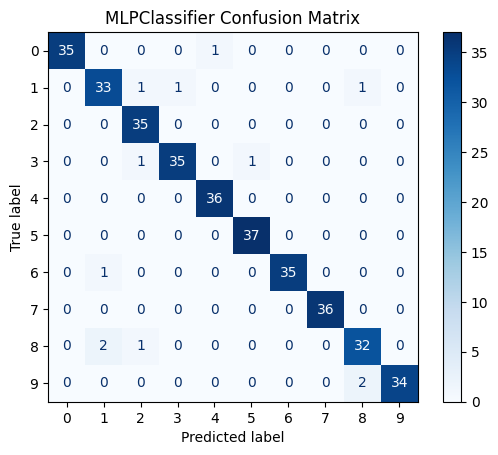

In [ ]:
# pip install scikit-learn matplotlib

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


# 1. 데이터 로드
digits = load_digits()

X = digits.data      # 8x8 이미지가 64차원 벡터로 펼쳐진 데이터
y = digits.target    # 정답 라벨: 0~9


# 2. 학습 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 3. MLP 모델 구성
# 신경망은 입력 스케일에 민감하므로 StandardScaler를 함께 사용
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 은닉층 2개: 64개 뉴런, 32개 뉴런
        activation="relu",
        solver="adam",
        alpha=0.0001,                 # L2 정규화 강도
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=100,
        random_state=42,
        early_stopping=True
    ))
])


# 4. 학습
model.fit(X_train, y_train)


# 5. 예측
y_pred = model.predict(X_test)


# 6. 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 7. Confusion Matrix 시각화
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=digits.target_names,
    cmap="Blues"
)

plt.title("MLPClassifier Confusion Matrix")
plt.show()